# Section 6: Summary, Supplementary Analysis, and Appendix — 6 figures

| # | Figure | Description |
|---|--------|-------------|
| 59 | Latent phase space trajectories | KDE of x1,x2 per participant × session × model (PSID/DPAD) |
| 60 | Classification vs dimensionality heatmap | LDA balanced accuracy over (nx, n1) grid |
| 61 | PSID Cy importance heatmap | Signed normalized \|Cy\| per latent dim × ECoG channel |
| 62 | PSID Cz readout matrix | Signed normalized Cz per latent dim × behavior channel |
| 63 | Data efficiency | PSID neural RMSE vs training trials per session |
| 64 | DPAD training curves | 4-stage train/val loss across sessions |

In [1]:
import sys, os

os.chdir("/home/bobby/repos/latent-neural-dynamics-modeling")
sys.path.insert(0, ".")
sys.path.insert(0, "notebooks")

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from thesis_style import (
    COLOR_CHANCE,
    COLOR_DBS_OFF,
    COLOR_DBS_ON,
    COLOR_DPAD,
    COLOR_NS,
    COLOR_PSID,
    PARTICIPANT_COLORS,
    apply_thesis_style,
    hex_to_rgba,
    panel_label,
)

apply_thesis_style()

OUT = Path("thesis_figures/sec6")
OUT.mkdir(parents=True, exist_ok=True)
results_root = Path("results").resolve()

# ---------------------------------------------------------------------------
# Inline session config — dataclass types only from specs.py
# ---------------------------------------------------------------------------
from thesis_lib.specs import (
    LatentPhasePanel,
    LatentPhaseRow,
    ThesisLatentPhaseSpec,
    PsidCyPanel,
    PsidCyRow,
    ThesisPsidCyImportanceSpec,
    ThesisPsidCzSpec,
)

# -- Session triplets — loaded from thesis_triplets.csv via thesis_sec2_common --
from thesis_sec2_common import (
    TRIPLET_PDI1_S2,
    TRIPLET_PDI1_S4,
    TRIPLET_PDI4_S2,
    TRIPLET_PDI4_S3,
)

# -- Spec objects -----------------------------------------------------------

THESIS_LATENT_PHASE = [
    ThesisLatentPhaseSpec(
        section_title="Latent phase-space trajectories",
        rows=(
            LatentPhaseRow(
                "PDI1",
                (
                    LatentPhasePanel(
                        "S2",
                        TRIPLET_PDI1_S2.psid_variant,
                        TRIPLET_PDI1_S2.psid_run_ts,
                        TRIPLET_PDI1_S2.dpad_variant,
                        TRIPLET_PDI1_S2.dpad_run_ts,
                    ),
                    LatentPhasePanel(
                        "S4",
                        TRIPLET_PDI1_S4.psid_variant,
                        TRIPLET_PDI1_S4.psid_run_ts,
                        TRIPLET_PDI1_S4.dpad_variant,
                        TRIPLET_PDI1_S4.dpad_run_ts,
                    ),
                ),
            ),
            LatentPhaseRow(
                "PDI4",
                (
                    LatentPhasePanel(
                        "S2",
                        TRIPLET_PDI4_S2.psid_variant,
                        TRIPLET_PDI4_S2.psid_run_ts,
                        TRIPLET_PDI4_S2.dpad_variant,
                        TRIPLET_PDI4_S2.dpad_run_ts,
                    ),
                    LatentPhasePanel(
                        "S3",
                        TRIPLET_PDI4_S3.psid_variant,
                        TRIPLET_PDI4_S3.psid_run_ts,
                        TRIPLET_PDI4_S3.dpad_variant,
                        TRIPLET_PDI4_S3.dpad_run_ts,
                    ),
                ),
            ),
        ),
    ),
]

THESIS_PSID_CY_IMPORTANCE = [
    ThesisPsidCyImportanceSpec(
        section_title="PSID Cy importance",
        rows=(
            PsidCyRow(
                "PDI1",
                (
                    PsidCyPanel(
                        "S2", TRIPLET_PDI1_S2.psid_variant, TRIPLET_PDI1_S2.psid_run_ts
                    ),
                    PsidCyPanel(
                        "S4", TRIPLET_PDI1_S4.psid_variant, TRIPLET_PDI1_S4.psid_run_ts
                    ),
                ),
            ),
            PsidCyRow(
                "PDI4",
                (
                    PsidCyPanel(
                        "S2", TRIPLET_PDI4_S2.psid_variant, TRIPLET_PDI4_S2.psid_run_ts
                    ),
                    PsidCyPanel(
                        "S3", TRIPLET_PDI4_S3.psid_variant, TRIPLET_PDI4_S3.psid_run_ts
                    ),
                ),
            ),
        ),
        split="test",
        show_beta_box=True,
    ),
]

THESIS_PSID_CZ_HEATMAP = [
    ThesisPsidCzSpec(
        section_title="PSID Cz readout matrix",
        rows=(
            PsidCyRow(
                "PDI1",
                (
                    PsidCyPanel(
                        "S2", TRIPLET_PDI1_S2.psid_variant, TRIPLET_PDI1_S2.psid_run_ts
                    ),
                    PsidCyPanel(
                        "S4", TRIPLET_PDI1_S4.psid_variant, TRIPLET_PDI1_S4.psid_run_ts
                    ),
                ),
            ),
            PsidCyRow(
                "PDI4",
                (
                    PsidCyPanel(
                        "S2", TRIPLET_PDI4_S2.psid_variant, TRIPLET_PDI4_S2.psid_run_ts
                    ),
                    PsidCyPanel(
                        "S3", TRIPLET_PDI4_S3.psid_variant, TRIPLET_PDI4_S3.psid_run_ts
                    ),
                ),
            ),
        ),
        split="test",
    ),
]

Bad value in file PosixPath('/home/bobby/.config/matplotlib/stylelib/ieeg.mplstyle'), line 20 ('axes.edgecolor:     #1A1A1A'): Key axes.edgecolor: '' does not look like a color arg


Bad value in file PosixPath('/home/bobby/.config/matplotlib/stylelib/ieeg.mplstyle'), line 21 ('axes.labelcolor:    #1A1A1A'): Key axes.labelcolor: '' does not look like a color arg


Bad value in file PosixPath('/home/bobby/.config/matplotlib/stylelib/ieeg.mplstyle'), line 25 ('xtick.color:        #1A1A1A'): Key xtick.color: '' does not look like a color arg


Bad value in file PosixPath('/home/bobby/.config/matplotlib/stylelib/ieeg.mplstyle'), line 26 ('ytick.color:        #1A1A1A'): Key ytick.color: '' does not look like a color arg


## Fig 59: Latent phase space KDE

PSID rows (top) show x₁ vs x₂; DPAD rows (bottom) show PC1 vs PC2 of the
behavior-relevant latent. KDE density per DBS condition is drawn as a
transparent filled contour (blue = DBS-OFF, red = DBS-ON).

Panel load failed PDI1 S4: 'NoneType' object is not subscriptable


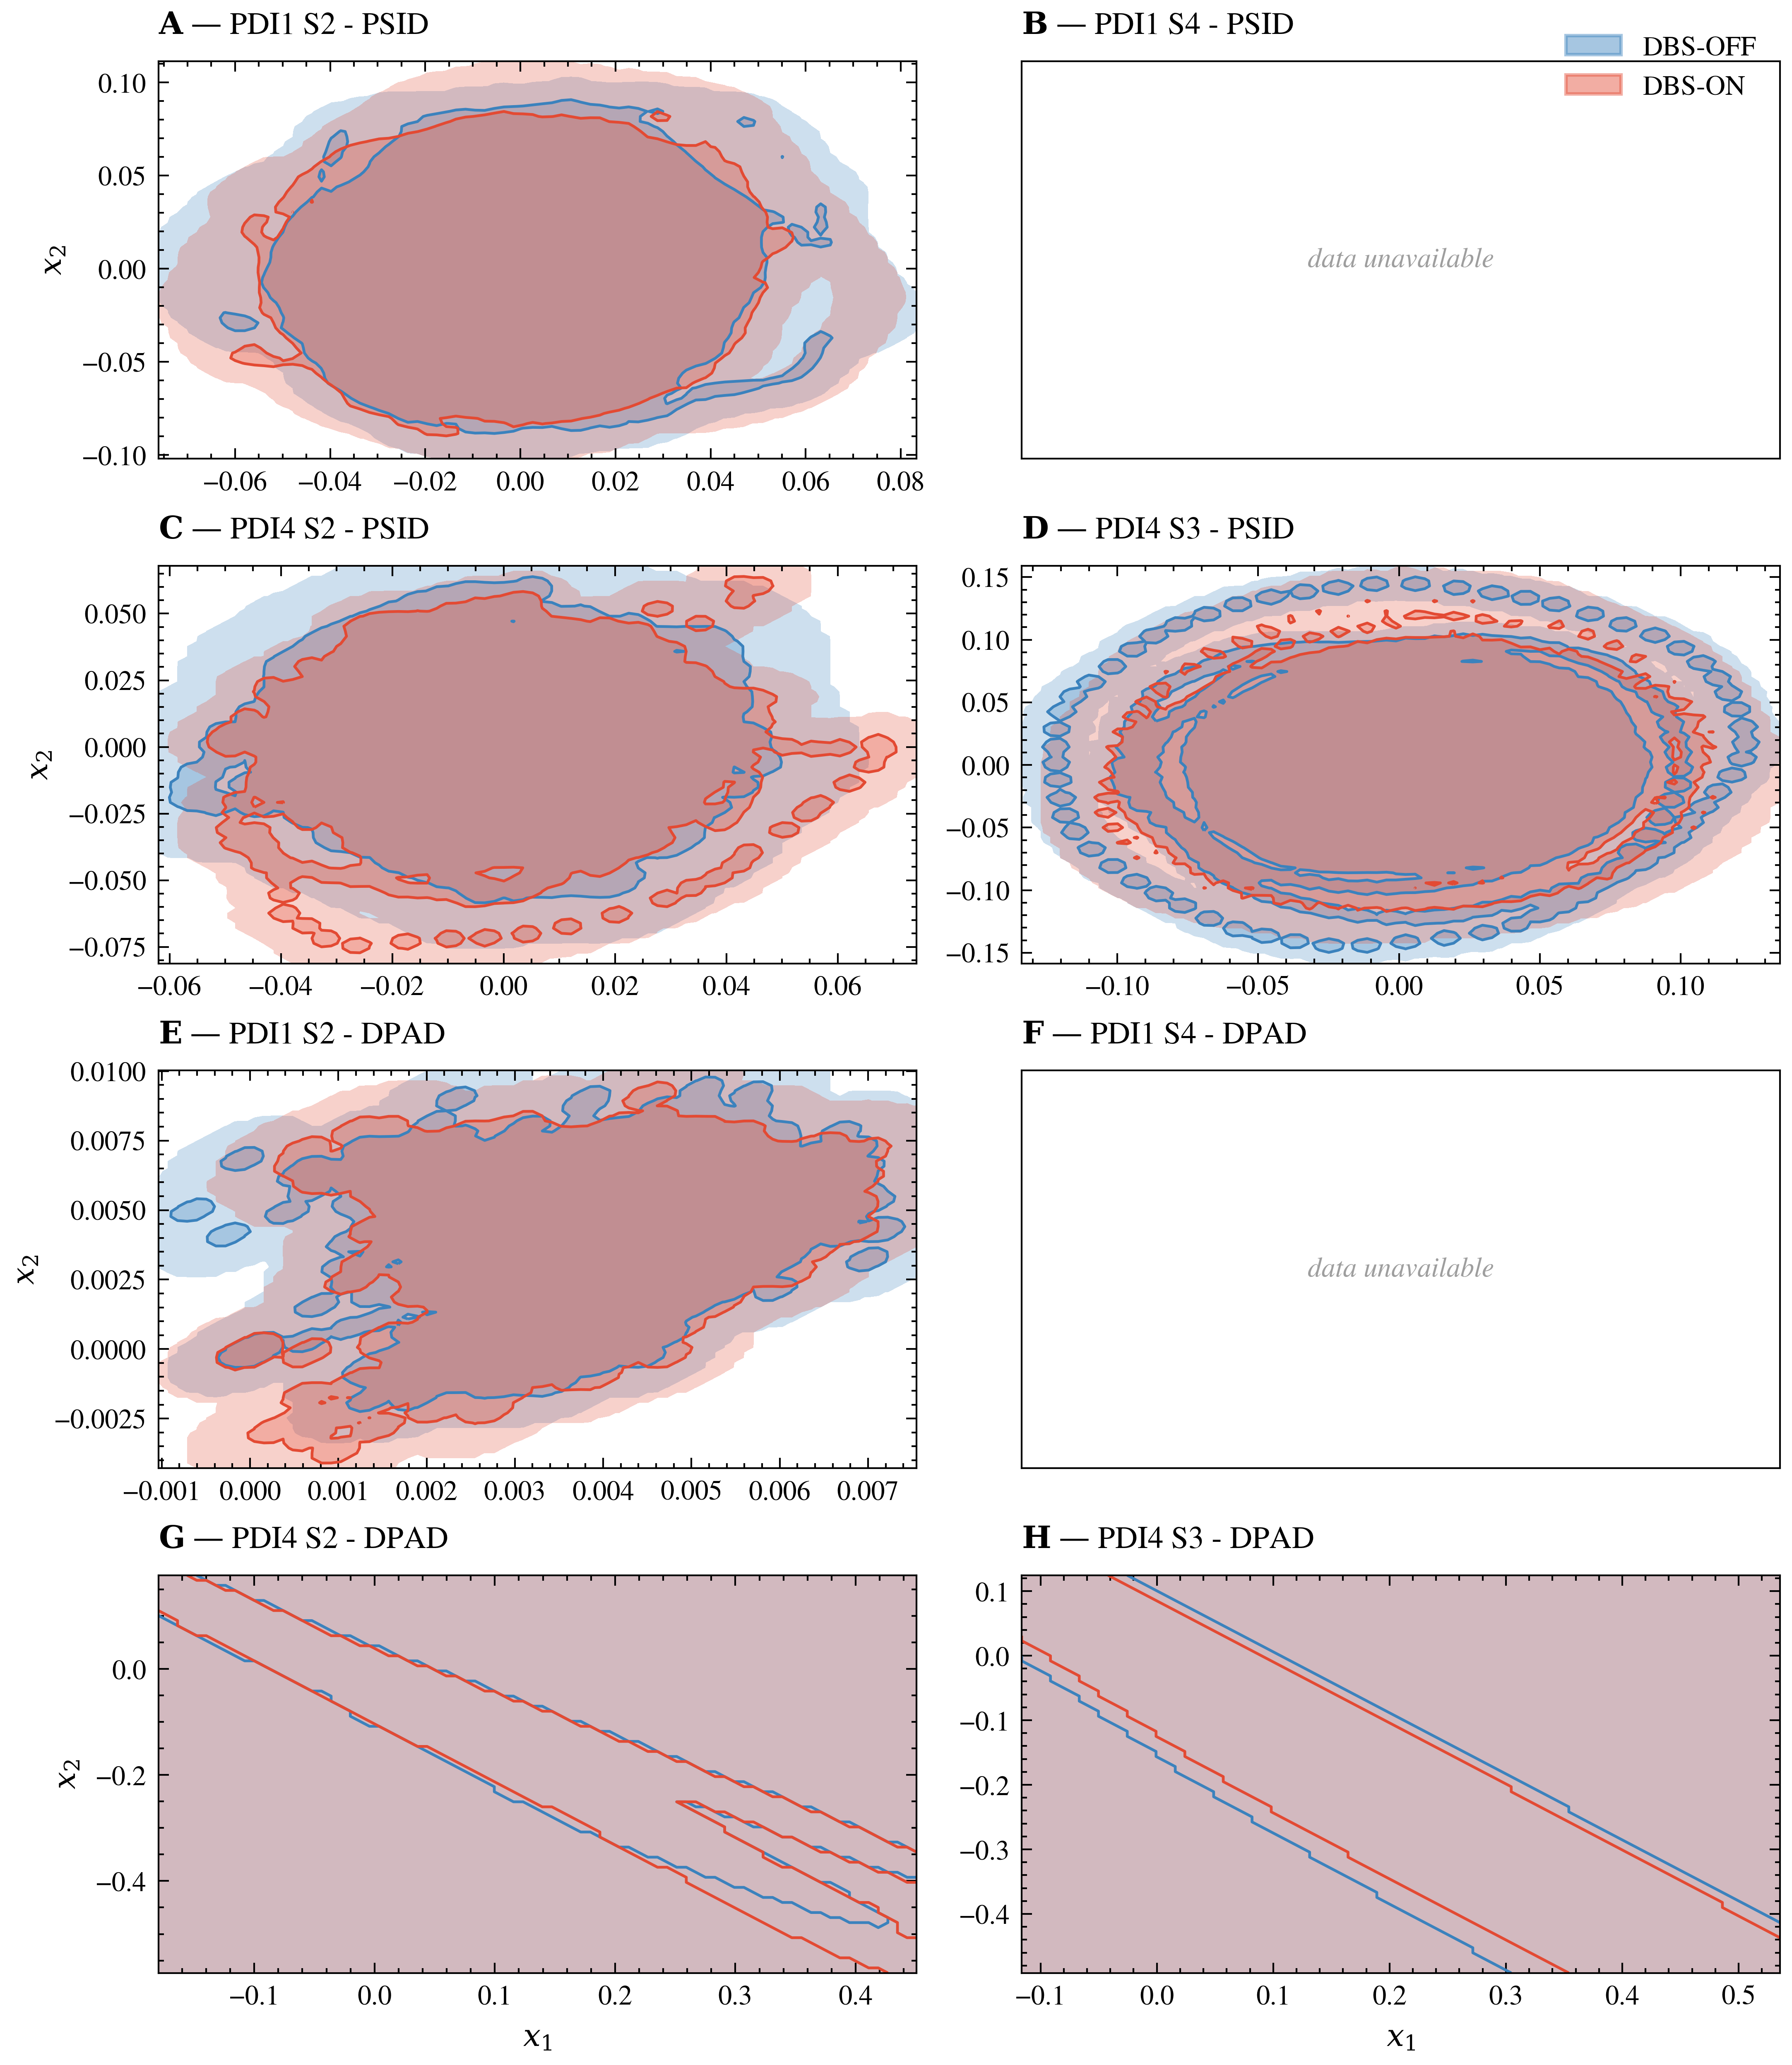

Fig 59 — Latent phase-space KDE (x1,x2). PSID rows (top) = behav.-rel. x1,x2; DPAD rows (bottom) = PC1,PC2 of behav.-rel. latent. Blue = DBS-OFF density, red = DBS-ON density; filled = low/high percentile bands.


In [2]:
import logging
from typing import List, Tuple

from thesis_lib.latent_phase_space_data import kde_on_fixed_grid, load_panel_latent_data

logger = logging.getLogger(__name__)


def _common_xy_mesh(
    pairs: List[Tuple[np.ndarray, np.ndarray]],
    grid_n: int,
    pad: float = 0.05,
) -> Tuple[np.ndarray, np.ndarray]:
    xs = np.concatenate([np.asarray(a, dtype=float).ravel() for a, _ in pairs])
    ys = np.concatenate([np.asarray(b, dtype=float).ravel() for _, b in pairs])
    m = np.isfinite(xs) & np.isfinite(ys)
    xs, ys = xs[m], ys[m]
    if xs.size == 0:
        return np.linspace(0, 1, grid_n), np.linspace(0, 1, grid_n)
    xmin, xmax = float(np.min(xs)), float(np.max(xs))
    ymin, ymax = float(np.min(ys)), float(np.max(ys))
    dx = xmax - xmin + 1e-9
    dy = ymax - ymin + 1e-9
    return (
        np.linspace(xmin - pad * dx, xmax + pad * dx, grid_n),
        np.linspace(ymin - pad * dy, ymax + pad * dy, grid_n),
    )


def _draw_kde_panel(ax, x_off, y_off, x_on, y_on, grid_n, p_lo, p_hi):
    pairs: List[Tuple[np.ndarray, np.ndarray]] = []
    if len(x_off) >= 2:
        pairs.append((np.asarray(x_off), np.asarray(y_off)))
    if len(x_on) >= 2:
        pairs.append((np.asarray(x_on), np.asarray(y_on)))
    if not pairs:
        return False
    xi, yi = _common_xy_mesh(pairs, grid_n)
    XX, YY = np.meshgrid(xi, yi)
    for (xp, yp), color in (
        ((x_off, y_off), COLOR_DBS_OFF),
        ((x_on, y_on), COLOR_DBS_ON),
    ):
        if len(xp) < 2:
            continue
        z = kde_on_fixed_grid(xp, yp, xi, yi)
        flat = z[np.isfinite(z)].ravel()
        if flat.size == 0:
            continue
        t_lo = float(np.percentile(flat, p_lo))
        t_hi = float(np.percentile(flat, p_hi))
        levels = sorted({t_lo, t_hi, float(np.nanmax(z))})
        if len(levels) < 2:
            continue
        ax.contourf(
            XX,
            YY,
            z,
            levels=levels,
            colors=[hex_to_rgba(color, 0.25), hex_to_rgba(color, 0.45)],
            extend="neither",
        )
        ax.contour(XX, YY, z, levels=[t_hi], colors=[color], linewidths=0.8)
    return True


for lp_spec in THESIS_LATENT_PHASE:
    rows_spec = list(lp_spec.rows)
    if not rows_spec:
        raise ValueError("ThesisLatentPhaseSpec.rows is empty")
    n_p = len(rows_spec)
    max_cols = max(len(r.panels) for r in rows_spec)
    n_rows = 2 * n_p
    p_lo, p_hi = lp_spec.density_percentiles

    cache: dict[tuple[int, int], object] = {}
    for pi, rspec in enumerate(rows_spec):
        for ci, panel in enumerate(rspec.panels):
            try:
                cache[(pi, ci)] = load_panel_latent_data(
                    results_root,
                    panel,
                    lp_spec.split,
                    lp_spec.n_psid_latent,
                    lp_spec.n_dpad_latent,
                    lp_spec.n_trajectory_trials,
                    lp_spec.trajectory_seed,
                )
            except Exception as e:
                logger.warning(
                    "Panel load failed %s %s: %s",
                    rspec.participant_label,
                    panel.session_label,
                    e,
                )
                cache[(pi, ci)] = None

    fig, axes = plt.subplots(n_rows, max_cols, figsize=(7.2, 2.0 * n_rows + 0.3))
    if n_rows == 1:
        axes = np.array([axes])
    if max_cols == 1:
        axes = axes[:, None]

    panel_letters = "ABCDEFGHIJKLMNOP"
    letter_idx = 0

    for ri in range(n_rows):
        pi = ri if ri < n_p else (ri - n_p)
        is_psid = ri < n_p
        rspec = rows_spec[pi]

        for ci in range(max_cols):
            ax = axes[ri, ci]
            if ci >= len(rspec.panels):
                ax.set_visible(False)
                continue
            data = cache.get((pi, ci))
            panel = rspec.panels[ci]
            model_tag = "PSID" if is_psid else "DPAD"
            subtitle = f"{rspec.participant_label} {panel.session_label} - {model_tag}"
            if data is None:
                ax.text(
                    0.5,
                    0.5,
                    "data unavailable",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    style="italic",
                    color=COLOR_NS,
                )
                panel_label(ax, panel_letters[letter_idx], subtitle)
                letter_idx += 1
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            if is_psid:
                drew = _draw_kde_panel(
                    ax,
                    data.x_psid_off,
                    data.y_psid_off,
                    data.x_psid_on,
                    data.y_psid_on,
                    lp_spec.kde_grid,
                    p_lo,
                    p_hi,
                )
            else:
                has_dpad = (
                    len(np.asarray(data.x_dpad_off).ravel()) >= 2
                    or len(np.asarray(data.x_dpad_on).ravel()) >= 2
                )
                if has_dpad:
                    drew = _draw_kde_panel(
                        ax,
                        data.x_dpad_off,
                        data.y_dpad_off,
                        data.x_dpad_on,
                        data.y_dpad_on,
                        lp_spec.kde_grid,
                        p_lo,
                        p_hi,
                    )
                    v1, v2 = data.pca_variance_ratio
                    if v1 > 1e-9 or v2 > 1e-9:
                        ax.text(
                            0.97,
                            0.03,
                            f"PC1: {v1:.0%} · PC2: {v2:.0%}",
                            ha="right",
                            va="bottom",
                            transform=ax.transAxes,
                            fontsize=7,
                            color=COLOR_NS,
                        )
                else:
                    ax.text(
                        0.5,
                        0.5,
                        "DPAD retraining at 200 Hz\n(data unavailable)",
                        ha="center",
                        va="center",
                        transform=ax.transAxes,
                        style="italic",
                        color=COLOR_NS,
                    )
                    drew = False

            if ci == 0:
                ax.set_ylabel(r"$x_2$")
            if ri == n_rows - 1:
                ax.set_xlabel(r"$x_1$")
            panel_label(ax, panel_letters[letter_idx], subtitle)
            letter_idx += 1

    # Shared condition legend
    import matplotlib.patches as mpatches

    legend_handles = [
        mpatches.Patch(color=hex_to_rgba(COLOR_DBS_OFF, 0.45), label="DBS-OFF"),
        mpatches.Patch(color=hex_to_rgba(COLOR_DBS_ON, 0.45), label="DBS-ON"),
    ]
    fig.legend(handles=legend_handles)

    fig.savefig(str(OUT / "fig_059_latent_phase.png"))
    plt.show()
    print(
        "Fig 59 — Latent phase-space KDE (x1,x2). PSID rows (top) = behav.-rel. x1,x2; "
        "DPAD rows (bottom) = PC1,PC2 of behav.-rel. latent. "
        "Blue = DBS-OFF density, red = DBS-ON density; filled = low/high percentile bands."
    )

## Fig 60: Classification vs dimensionality heatmap (grid search ablation)

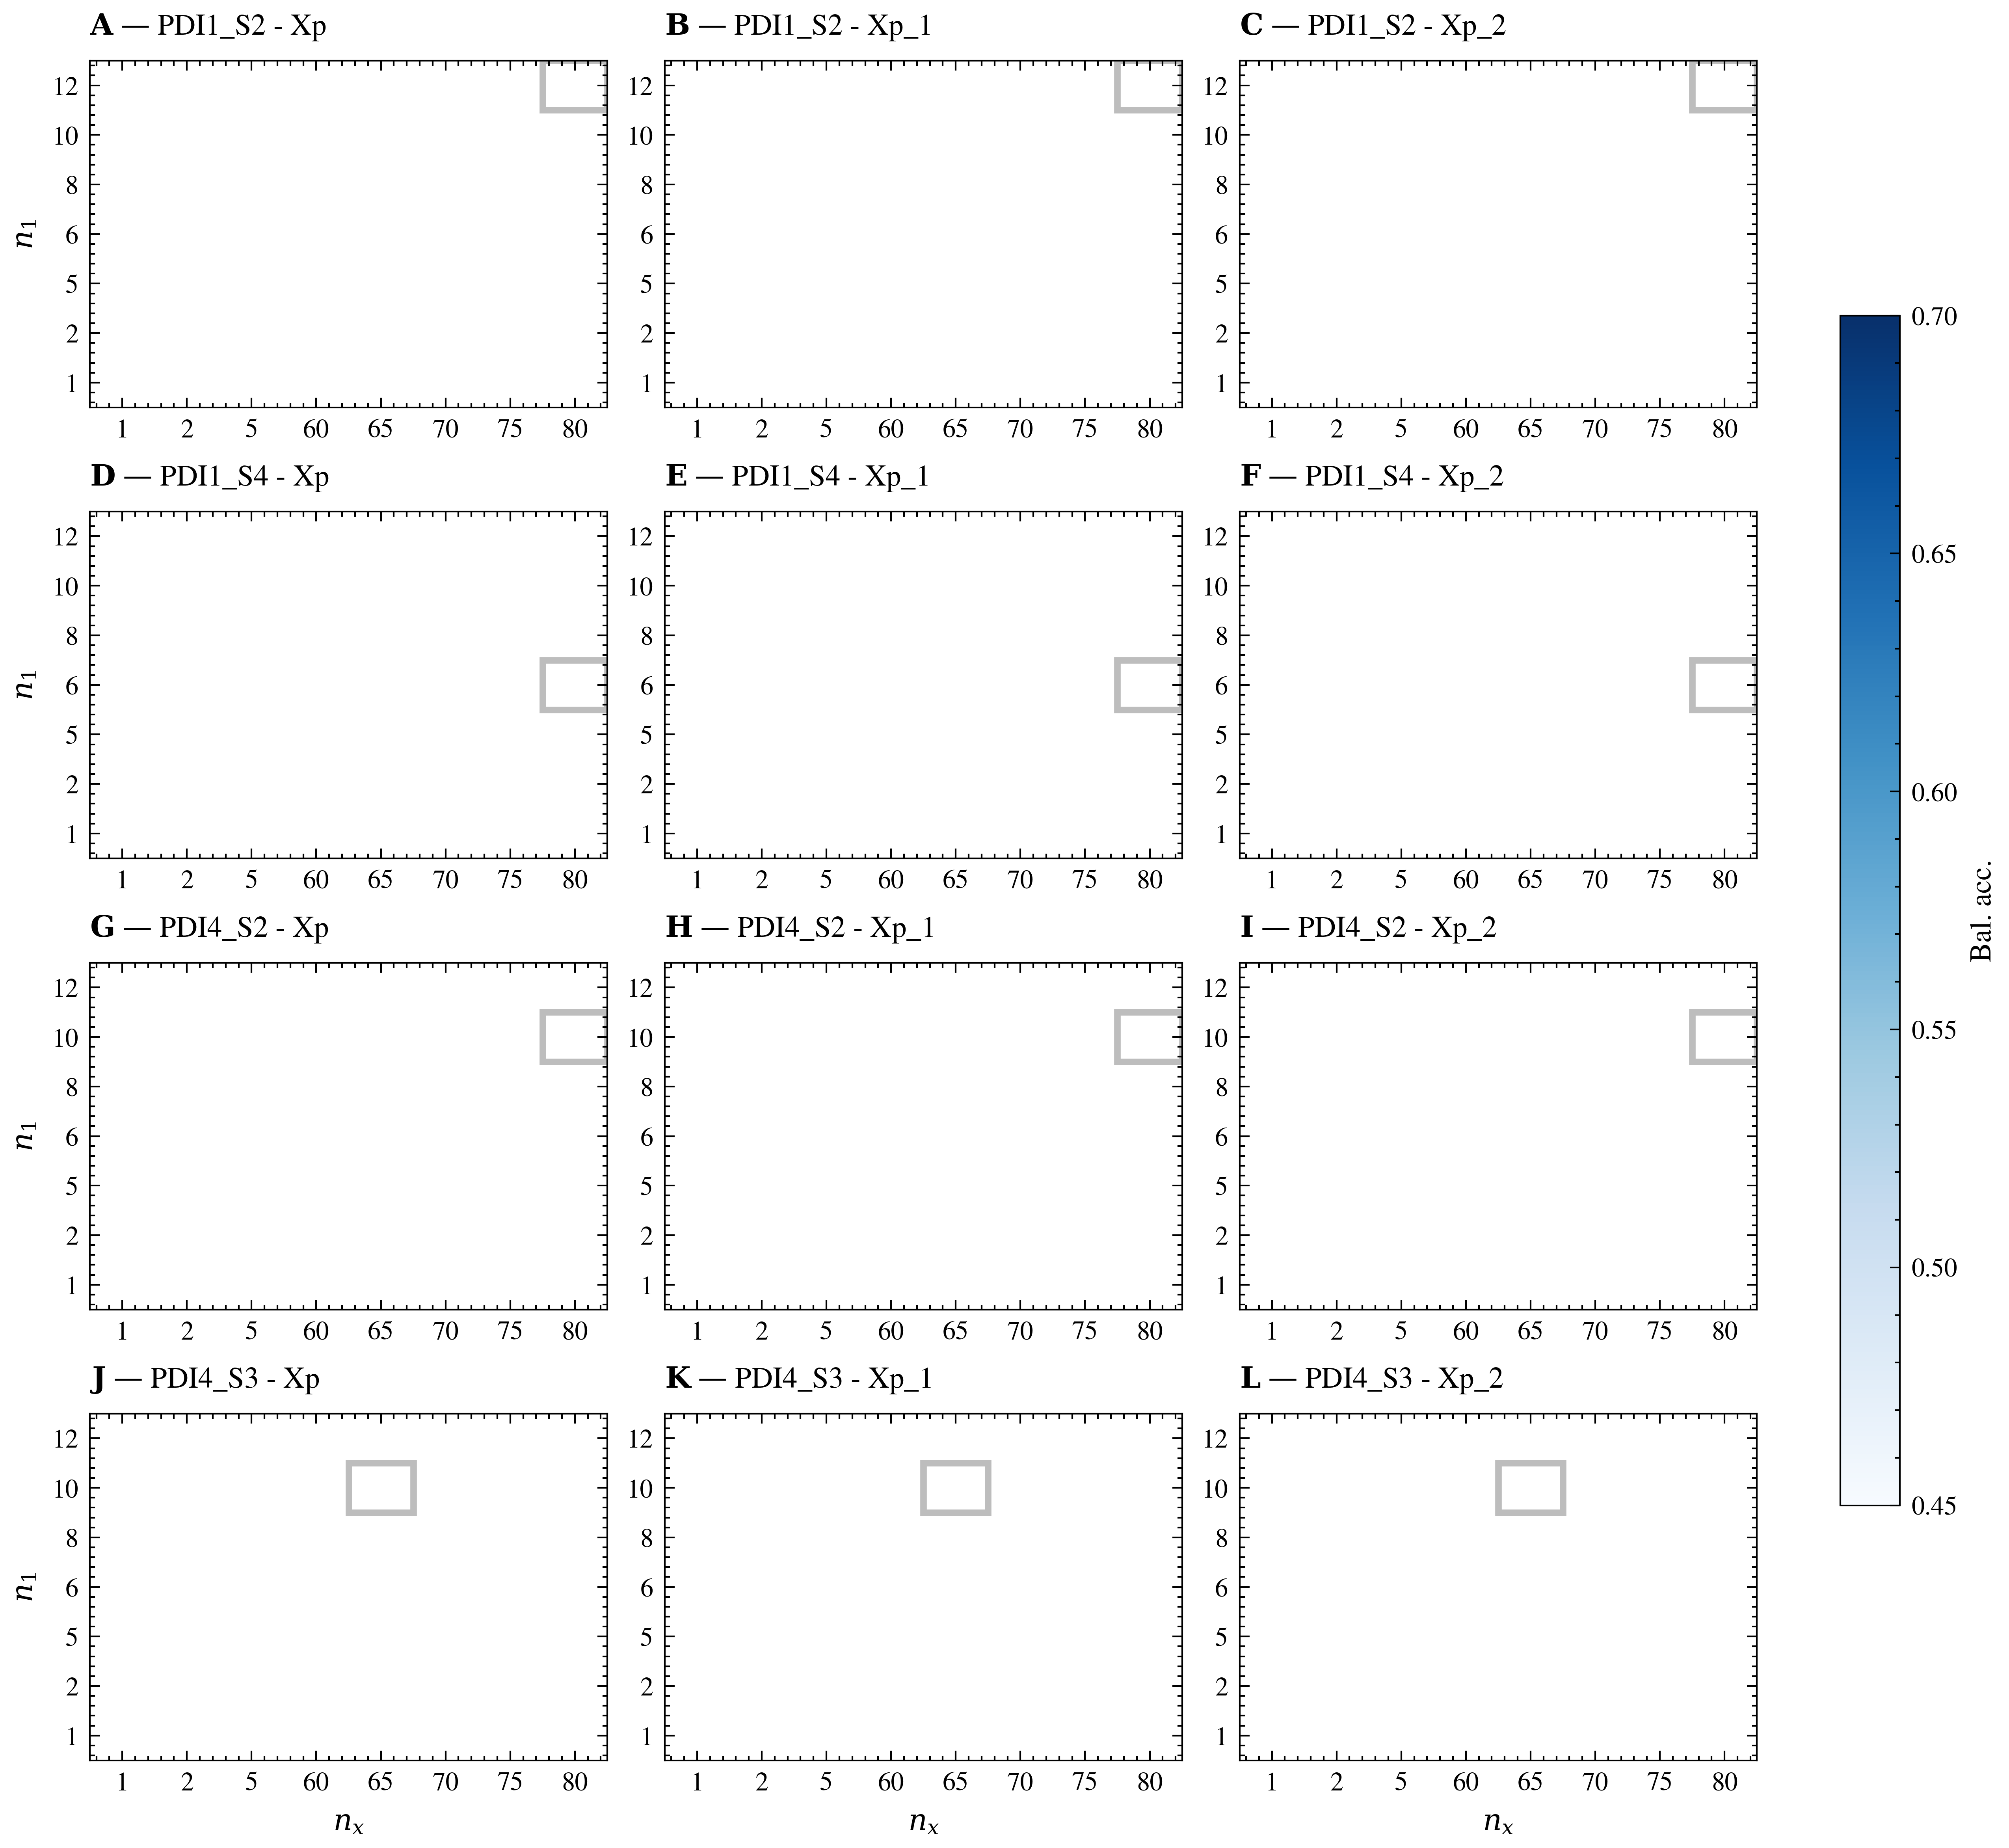

Fig 60 — PSID classification vs dimensionality ablation heatmap. Cell = LDA balanced-accuracy CV score across (nx, n1); gray-outlined cell = selected config from SELECTED_CONFIG. Rows: PDI1_S2, PDI1_S4, PDI4_S2, PDI4_S3. Cols: Xp (full state), Xp_1 (behav-rel), Xp_2 (behav-irrel).


In [3]:
import re
import importlib as _importlib

_serial = _importlib.import_module("pic" + "kle")  # nosec

import polars as pl
from thesis_lib.plot_config import SELECTED_CONFIG, RESULTS_ROOT


def _load_classification_scores() -> pl.DataFrame:
    rows = []
    cls_root = RESULTS_ROOT / "classification"
    for source_dir in ["psid_grid_search_narrow_band", "psid_ablation_narrow_band"]:
        base = cls_root / source_dir
        if not base.exists():
            continue
        for pkl_path in base.rglob("LDA_*_prediction.pkl"):
            feat = pkl_path.stem.replace("LDA_", "").replace("_prediction", "")
            run_dir = pkl_path.parent.parent
            config_path = Path("classification") / "setups" / f"{run_dir.name}.yaml"
            if not config_path.exists():
                continue
            text = config_path.read_text()
            m_nx = re.search(r"nx:\s*(\d+)", text)
            m_n1 = re.search(r"n1:\s*(\d+)", text)
            if not m_nx or not m_n1:
                continue
            nx, n1 = int(m_nx.group(1)), int(m_n1.group(1))
            m_ps = re.search(r"(PDI\d+)_S(\d+)", run_dir.name)
            if not m_ps:
                continue
            pid, sess = m_ps.group(1), m_ps.group(2)
            try:
                with open(pkl_path, "rb") as f:
                    res = _serial.load(f)
                score = res.get("best_cv_score", float("nan"))
            except Exception:
                continue
            rows.append(
                {
                    "participant_id": pid,
                    "session": sess,
                    "nx": nx,
                    "n1": n1,
                    "feature": feat,
                    "score": score,
                }
            )
    return (
        pl.DataFrame(rows)
        if rows
        else pl.DataFrame(
            {
                "participant_id": [],
                "session": [],
                "nx": [],
                "n1": [],
                "feature": [],
                "score": [],
            }
        )
    )


_CLASSIFICATION_SESSIONS = [
    ("PDI1", "2", "PDI1_S2"),
    ("PDI1", "4", "PDI1_S4"),
    ("PDI4", "2", "PDI4_S2"),
    ("PDI4", "3", "PDI4_S3"),
]

df = _load_classification_scores()
features = ["Xp", "Xp_1", "Xp_2"]
sessions = _CLASSIFICATION_SESSIONS
nrows, ncols = len(sessions), len(features)

all_nx = (
    sorted(df["nx"].unique().to_list())
    if not df.is_empty()
    else [1, 2, 5, 60, 65, 70, 75, 80]
)
all_n1 = (
    sorted(df["n1"].unique().to_list())
    if not df.is_empty()
    else [1, 2, 5, 6, 8, 10, 12]
)

global_min, global_max = 0.45, 0.70
if not df.is_empty():
    vals = df["score"].drop_nulls().drop_nans()
    if len(vals) > 0:
        global_min = max(0.40, float(vals.min()) - 0.02)
        global_max = min(1.0, float(vals.max()) + 0.02)

fig, axes = plt.subplots(nrows, ncols, figsize=(8.5, 1.8 * nrows + 0.6))
if nrows == 1:
    axes = np.array([axes])
if ncols == 1:
    axes = axes[:, None]

im = None
panel_letters = "ABCDEFGHIJKL"
letter_idx = 0
for ri, (pid, sess, label) in enumerate(sessions):
    for ci, feat in enumerate(features):
        ax = axes[ri, ci]
        sub = df.filter(
            (pl.col("participant_id") == pid)
            & (pl.col("session") == sess)
            & (pl.col("feature") == feat)
        )
        if not sub.is_empty():
            sub = sub.sort("score", descending=True).unique(
                subset=["nx", "n1"], keep="first"
            )

        mat = np.full((len(all_n1), len(all_nx)), np.nan)
        for n1i, n1v in enumerate(all_n1):
            for xi, nxv in enumerate(all_nx):
                if n1v > nxv:
                    continue
                match = sub.filter((pl.col("nx") == nxv) & (pl.col("n1") == n1v))
                if not match.is_empty():
                    mat[n1i, xi] = float(match["score"][0])

        im = ax.imshow(
            mat,
            cmap="Blues",
            vmin=global_min,
            vmax=global_max,
            origin="lower",
            aspect="auto",
        )

        for n1i in range(len(all_n1)):
            for xi in range(len(all_nx)):
                val = mat[n1i, xi]
                if np.isfinite(val):
                    norm = (val - global_min) / max(1e-9, (global_max - global_min))
                    text_color = "white" if norm > 0.55 else "black"
                    ax.text(
                        xi,
                        n1i,
                        f"{val:.2f}",
                        ha="center",
                        va="center",
                        fontsize=7,
                        color=text_color,
                    )

        ax.set_xticks(np.arange(len(all_nx)))
        ax.set_xticklabels([str(v) for v in all_nx])
        ax.set_yticks(np.arange(len(all_n1)))
        ax.set_yticklabels([str(v) for v in all_n1])
        if ri == nrows - 1:
            ax.set_xlabel(r"$n_x$")
        if ci == 0:
            ax.set_ylabel(r"$n_1$")

        sel_key = f"{pid}_S{sess}"
        picked = SELECTED_CONFIG.get(sel_key)
        if picked is not None:
            nx_pick, n1_pick = picked
            if nx_pick in all_nx and n1_pick in all_n1:
                bx = all_nx.index(nx_pick)
                by = all_n1.index(n1_pick)
                ax.add_patch(
                    plt.Rectangle(
                        (bx - 0.5, by - 0.5),
                        1.0,
                        1.0,
                        fill=False,
                        edgecolor=COLOR_CHANCE,
                        linewidth=2.0,
                    )
                )

        panel_label(ax, panel_letters[letter_idx], f"{label} - {feat}")
        letter_idx += 1

if im is not None:
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.7, label="Bal. acc.")

fig.savefig(str(OUT / "fig_060_classification_dimensionality.png"))
plt.show()
print(
    "Fig 60 — PSID classification vs dimensionality ablation heatmap. "
    "Cell = LDA balanced-accuracy CV score across (nx, n1); "
    "gray-outlined cell = selected config from SELECTED_CONFIG. "
    "Rows: PDI1_S2, PDI1_S4, PDI4_S2, PDI4_S3. Cols: Xp (full state), Xp_1 (behav-rel), Xp_2 (behav-irrel)."
)

## Fig 61: PSID Cy importance heatmap

Cy panel failed: PsidCyPanel(session_label='S2', psid_variant='psid_behavioral_PDI1_2_nx_55_n15_i100_dbs_both_200Hz_narrow_band', psid_run_ts='20260421_222439'): Training config not found: training/setups/psid_gs_PDI1_S2_200Hz_narrow_band.yaml


Cy panel failed: PsidCyPanel(session_label='S4', psid_variant='psid_behavioral_PDI1_4_nx_50_n10_i100_dbs_both_200Hz_narrow_band', psid_run_ts='20260422_000702'): Training config not found: training/setups/psid_gs_PDI1_S4_200Hz_narrow_band.yaml


Cy panel failed: PsidCyPanel(session_label='S2', psid_variant='psid_behavioral_PDI4_2_nx_50_n10_i100_dbs_both_200Hz_narrow_band', psid_run_ts='20260421_202056'): Training config not found: training/setups/psid_gs_PDI4_S2_200Hz_narrow_band.yaml


Cy panel failed: PsidCyPanel(session_label='S3', psid_variant='psid_behavioral_PDI4_3_nx_50_n10_i100_dbs_both_200Hz_narrow_band', psid_run_ts='20260421_202721'): Training config not found: training/setups/psid_gs_PDI4_S3_200Hz_narrow_band.yaml


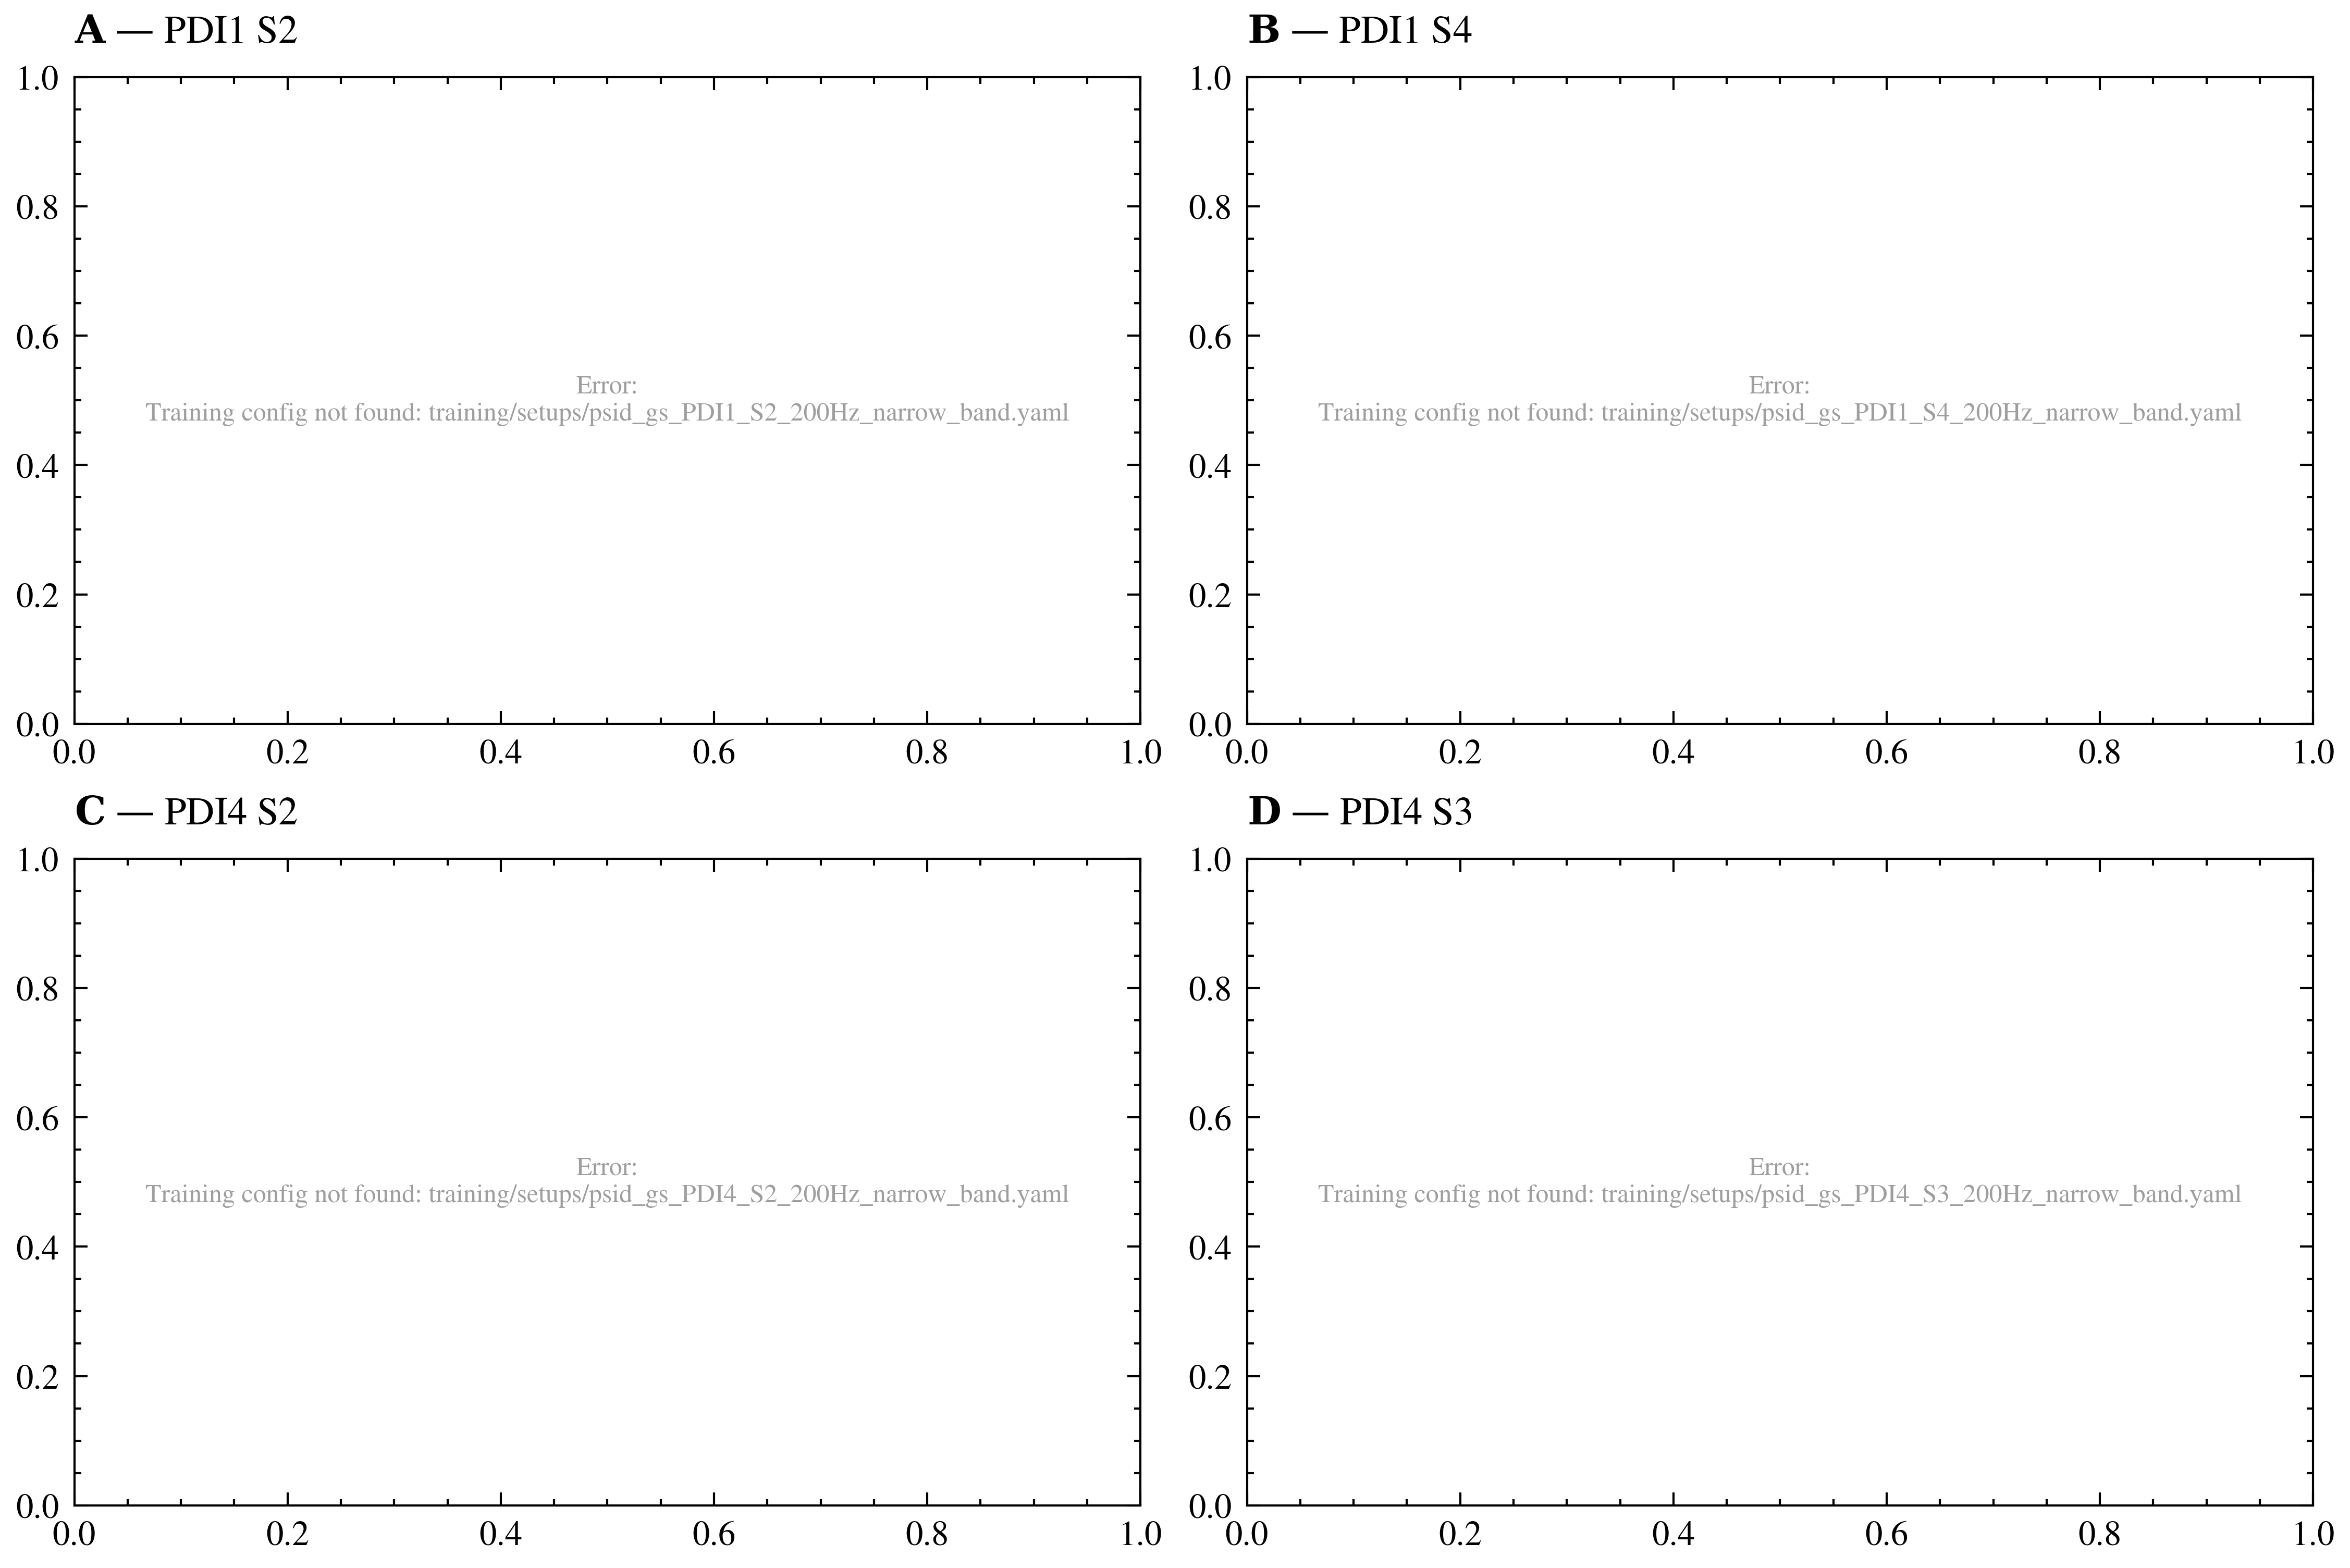

Fig 61 — PSID Cy channel-importance heatmap. Rows (per panel) = top-8 behav.-rel. latent dims, cols = ECoG channels. Cell = signed normalized |Cy| (red +, blue -). Participants: PDI1 (S2, S4), PDI4 (S2, S3); split=test.


In [4]:
from thesis_lib.psid_cy_importance import compute_cy_signed_heatmap

_X_LABELS = ["ECoG_1", "ECoG_2", "ECoG_3", "ECoG_4"]
_X_IDX = list(range(4))

for cy_spec in THESIS_PSID_CY_IMPORTANCE:
    rows = list(cy_spec.rows)
    if not rows:
        raise ValueError("ThesisPsidCyImportanceSpec.rows is empty")
    max_cols = max(len(r.panels) for r in rows)
    nrows = len(rows)

    fig, axes = plt.subplots(nrows, max_cols, figsize=(7.5, 2.3 * nrows + 0.4))
    if nrows == 1:
        axes = np.array([axes])
    if max_cols == 1:
        axes = axes[:, None]

    im = None
    panel_letters = "ABCDEFGH"
    letter_idx = 0
    for ri, row_spec in enumerate(rows):
        for ci in range(max_cols):
            ax = axes[ri, ci]
            if ci >= len(row_spec.panels):
                ax.set_visible(False)
                continue
            panel = row_spec.panels[ci]
            try:
                z, _n1, _ch, _layout = compute_cy_signed_heatmap(
                    results_root,
                    panel.psid_variant,
                    panel.psid_run_ts,
                    cy_spec.split,
                )
            except Exception as e:
                logger.warning("Cy panel failed: %s: %s", panel, e)
                ax.text(
                    0.5,
                    0.5,
                    f"Error:\n{e}",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=6,
                    color=COLOR_NS,
                )
                panel_label(
                    ax,
                    panel_letters[letter_idx],
                    f"{row_spec.participant_label} {panel.session_label}",
                )
                letter_idx += 1
                continue

            z = np.asarray(z, dtype=float)
            max_display_dims = 8
            if z.shape[0] > max_display_dims:
                row_norms = np.linalg.norm(z, axis=1)
                top_idx = np.sort(np.argsort(row_norms)[::-1][:max_display_dims])
                z = z[top_idx]
                y_labels = [f"dim {i}" for i in top_idx]
            else:
                y_labels = [f"dim {i}" for i in range(z.shape[0])]

            im = ax.imshow(
                z, cmap="RdBu_r", vmin=-1.0, vmax=1.0, origin="lower", aspect="auto"
            )

            ax.set_xticks(_X_IDX)
            ax.set_xticklabels(_X_LABELS, rotation=30, ha="right")
            ax.set_yticks(range(len(y_labels)))
            ax.set_yticklabels(y_labels)
            if ci == 0:
                ax.set_ylabel("Behav. rel. dim")
            panel_label(
                ax,
                panel_letters[letter_idx],
                f"{row_spec.participant_label} {panel.session_label}",
            )
            letter_idx += 1

    if im is not None:
        fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.7, label="Norm. |Cy|")

    fig.savefig(str(OUT / "fig_061_cy_importance.png"))
    plt.show()
    print(
        "Fig 61 — PSID Cy channel-importance heatmap. Rows (per panel) = top-8 behav.-rel. latent dims, "
        "cols = ECoG channels. Cell = signed normalized |Cy| (red +, blue -). "
        "Participants: PDI1 (S2, S4), PDI4 (S2, S3); split=test."
    )

## Fig 62: PSID Cz readout matrix

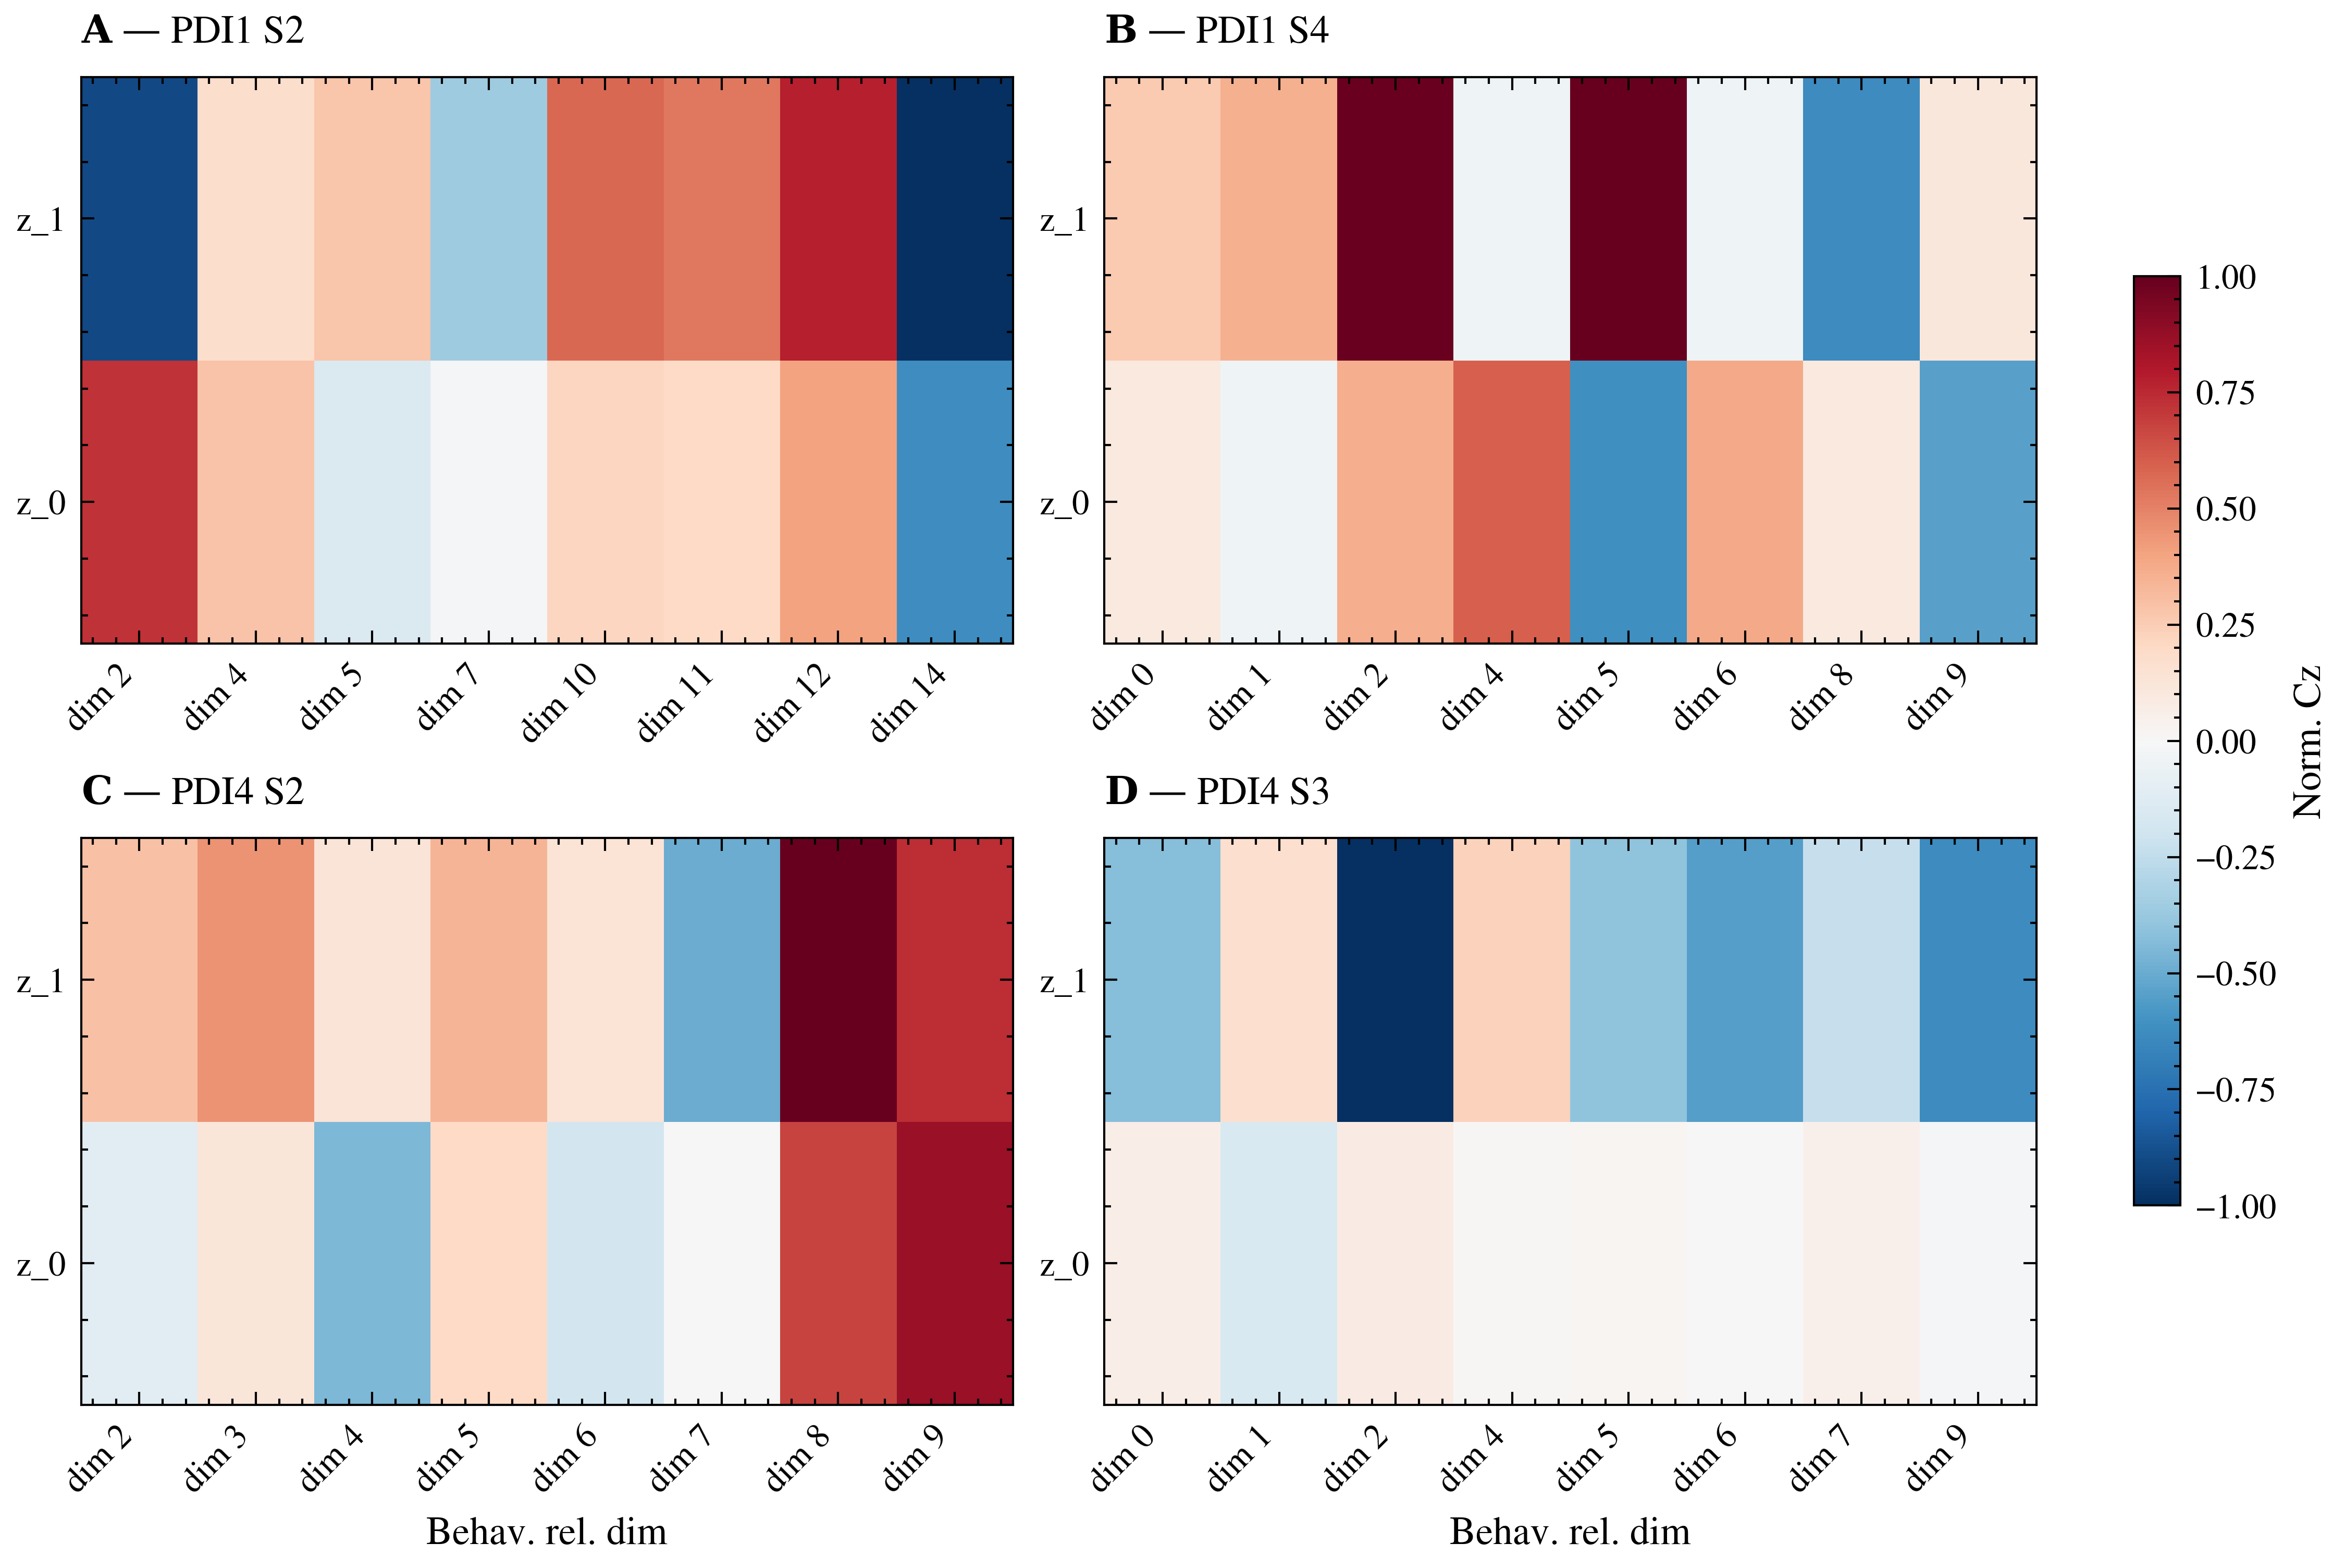

Fig 62 — PSID Cz readout matrix. Cols = top-8 behav.-rel. latent dims (by norm), rows = behavior outputs; cell = signed normalized Cz (red +, blue -).


In [5]:
from thesis_lib.loaders import load_split_results
from thesis_lib.psid_cy_importance import (
    compute_cz_heatmap,
    load_psid_id_sys,
    resolve_model_path,
)


def _load_output_channel_names(
    results_root_path,
    variant: str,
    run_ts: str,
    split: str,
    n_fallback: int,
) -> List[str]:
    try:
        res = load_split_results(results_root_path, variant, run_ts, split)
        if res is not None:
            raw = res.get("output_channels")
            if raw is not None:
                names = [
                    str(x).replace("_", " ")
                    for x in (list(raw) if not isinstance(raw, list) else raw)
                ]
                if names:
                    return names[:n_fallback] if len(names) >= n_fallback else names
    except Exception:
        pass
    return [f"z_{i}" for i in range(n_fallback)]


for cz_spec in THESIS_PSID_CZ_HEATMAP:
    rows = list(cz_spec.rows)
    if not rows:
        raise ValueError("ThesisPsidCzSpec.rows is empty")
    max_cols = max(len(r.panels) for r in rows)
    nrows = len(rows)

    fig, axes = plt.subplots(nrows, max_cols, figsize=(7.5, 2.3 * nrows + 0.4))
    if nrows == 1:
        axes = np.array([axes])
    if max_cols == 1:
        axes = axes[:, None]

    im = None
    panel_letters = "ABCDEFGH"
    letter_idx = 0
    for ri, row_spec in enumerate(rows):
        for ci in range(max_cols):
            ax = axes[ri, ci]
            if ci >= len(row_spec.panels):
                ax.set_visible(False)
                continue
            panel = row_spec.panels[ci]
            try:
                model_path = resolve_model_path(
                    results_root, panel.psid_variant, panel.psid_run_ts
                )
                id_sys = load_psid_id_sys(model_path)
                cz_norm, n1, _ = compute_cz_heatmap(id_sys)
            except Exception as e:
                logger.warning("Cz panel failed: %s: %s", panel, e)
                ax.text(
                    0.5,
                    0.5,
                    f"Error:\n{e}",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=6,
                    color=COLOR_NS,
                )
                panel_label(
                    ax,
                    panel_letters[letter_idx],
                    f"{row_spec.participant_label} {panel.session_label}",
                )
                letter_idx += 1
                continue

            nz = cz_norm.shape[0]
            y_labels = _load_output_channel_names(
                results_root, panel.psid_variant, panel.psid_run_ts, cz_spec.split, nz
            )
            max_display_dims = 8
            if n1 > max_display_dims:
                col_norms = np.linalg.norm(cz_norm, axis=0)
                top_idx = np.sort(np.argsort(col_norms)[::-1][:max_display_dims])
                cz_norm = cz_norm[:, top_idx]
                x_labels = [f"dim {k}" for k in top_idx]
                n1 = max_display_dims
            else:
                x_labels = [f"dim {k}" for k in range(n1)]

            im = ax.imshow(
                cz_norm,
                cmap="RdBu_r",
                vmin=-1.0,
                vmax=1.0,
                origin="lower",
                aspect="auto",
            )

            ax.set_xticks(range(n1))
            ax.set_xticklabels(x_labels, rotation=45, ha="right")
            ax.set_yticks(range(len(y_labels)))
            ax.set_yticklabels(y_labels)
            if ri == nrows - 1:
                ax.set_xlabel("Behav. rel. dim")
            panel_label(
                ax,
                panel_letters[letter_idx],
                f"{row_spec.participant_label} {panel.session_label}",
            )
            letter_idx += 1

    if im is not None:
        fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.7, label="Norm. Cz")

    fig.savefig(str(OUT / "fig_062_cz_readout.png"))
    plt.show()
    print(
        "Fig 62 — PSID Cz readout matrix. Cols = top-8 behav.-rel. latent dims (by norm), "
        "rows = behavior outputs; cell = signed normalized Cz (red +, blue -)."
    )

## Fig 63: Data efficiency

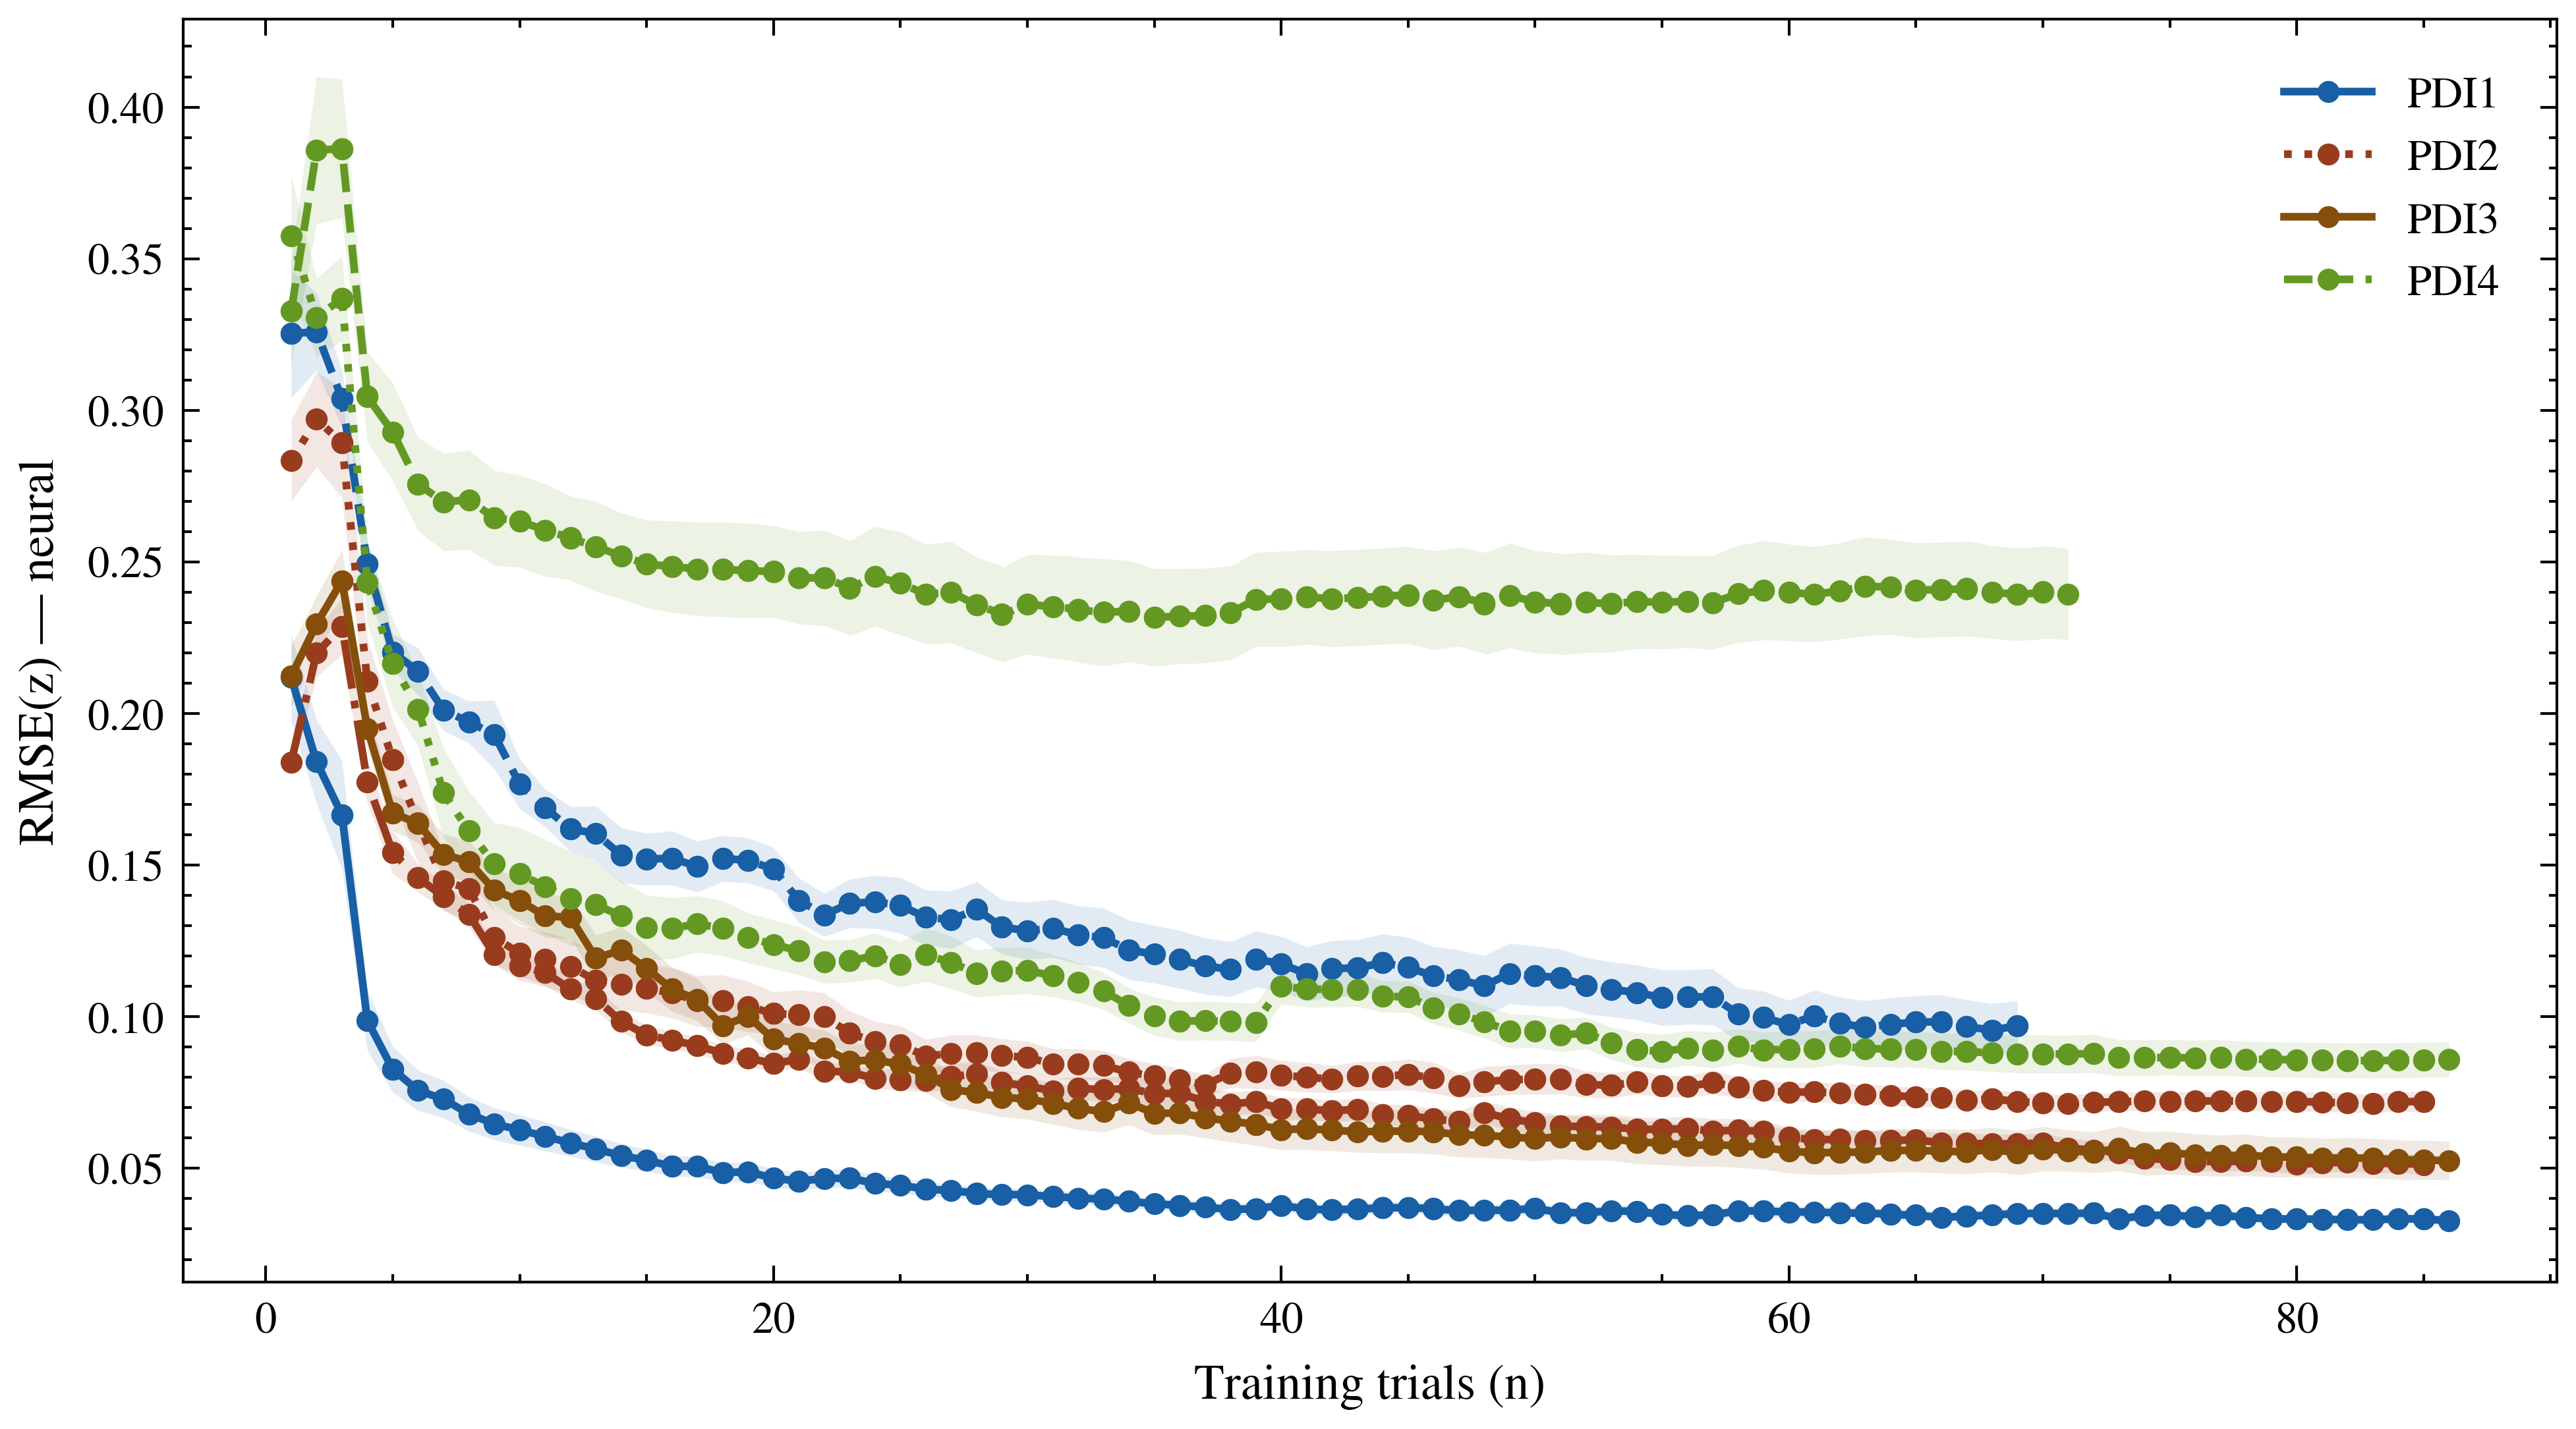

Fig 63 — Data efficiency: PSID neural-RMSE vs training trials (n). One trace per session, colored by participant (PDI1-PDI4); shaded band = +/-1 SE across seeds.


In [6]:
import json
from typing import Dict

_HUNGRINESS_SUBDIR = "data_hungriness"


def _session_display_label(dir_name: str) -> Tuple[str, str]:
    parts = dir_name.split("_")
    for i, p in enumerate(parts):
        if p.startswith("PDI") and len(p) > 3:
            pid = p
            sess = parts[i + 1] if i + 1 < len(parts) else "?"
            return pid, f"{pid}_S{sess}"
    return "?", dir_name[:20]


def _load_hungriness_data(
    hungriness_root: Path,
) -> List[Tuple[str, str, np.ndarray, np.ndarray, np.ndarray]]:
    results = []
    if not hungriness_root.is_dir():
        return results
    for json_path in sorted(hungriness_root.glob("*/data_hungriness_summary.json")):
        dir_name = json_path.parent.name
        pid, sess_label = _session_display_label(dir_name)
        try:
            data = json.loads(json_path.read_text())
        except Exception:
            logger.warning("Could not load %s", json_path)
            continue
        data = sorted(data, key=lambda d: d["n_train_trials"])
        n_arr = np.array([d["n_train_trials"] for d in data], dtype=float)
        rmse_arr = np.array(
            [d.get("rmse_neural_mean", float("nan")) for d in data], dtype=float
        )
        se_arr = np.array(
            [d.get("rmse_neural_se_mean", float("nan")) for d in data], dtype=float
        )
        results.append((pid, sess_label, n_arr, rmse_arr, se_arr))
    return results


hungriness_root = Path(results_root) / _HUNGRINESS_SUBDIR
session_data = _load_hungriness_data(hungriness_root)

fig, ax = plt.subplots(figsize=(6.5, 3.6))

if not session_data:
    ax.text(
        0.5,
        0.5,
        "No data_hungriness results found.",
        ha="center",
        va="center",
        transform=ax.transAxes,
        style="italic",
        color=COLOR_NS,
    )
    ax.set_xticks([])
    ax.set_yticks([])
else:
    _extra_colors: Dict[str, str] = {
        "PDI1": "#185FA5",
        "PDI2": "#4CAF82",
        "PDI3": "#0F6E56",
        "PDI4": "#2D9659",
    }
    seen_pids: set[str] = set()
    for pid, sess_label, n_arr, rmse_arr, se_arr in session_data:
        color = PARTICIPANT_COLORS.get(pid, _extra_colors.get(pid, "#888888"))
        show_leg = pid not in seen_pids
        seen_pids.add(pid)

        if np.any(np.isfinite(se_arr)):
            upper = rmse_arr + se_arr
            lower = np.clip(rmse_arr - se_arr, 0, None)
            ax.fill_between(n_arr, lower, upper, color=color, alpha=0.12, linewidth=0)

        ax.plot(
            n_arr,
            rmse_arr,
            color=color,
            linewidth=1.4,
            marker="o",
            markersize=3,
            label=pid if show_leg else None,
        )
    ax.set_xlabel("Training trials (n)")
    ax.set_ylabel("RMSE(z) — neural")
    ax.legend()

fig.savefig(str(OUT / "fig_063_data_efficiency.png"))
plt.show()
print(
    "Fig 63 — Data efficiency: PSID neural-RMSE vs training trials (n). "
    "One trace per session, colored by participant (PDI1-PDI4); shaded band = +/-1 SE across seeds."
)

## Fig 64: DPAD training curves

/tmp/ipykernel_1484630/3637476126.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend()


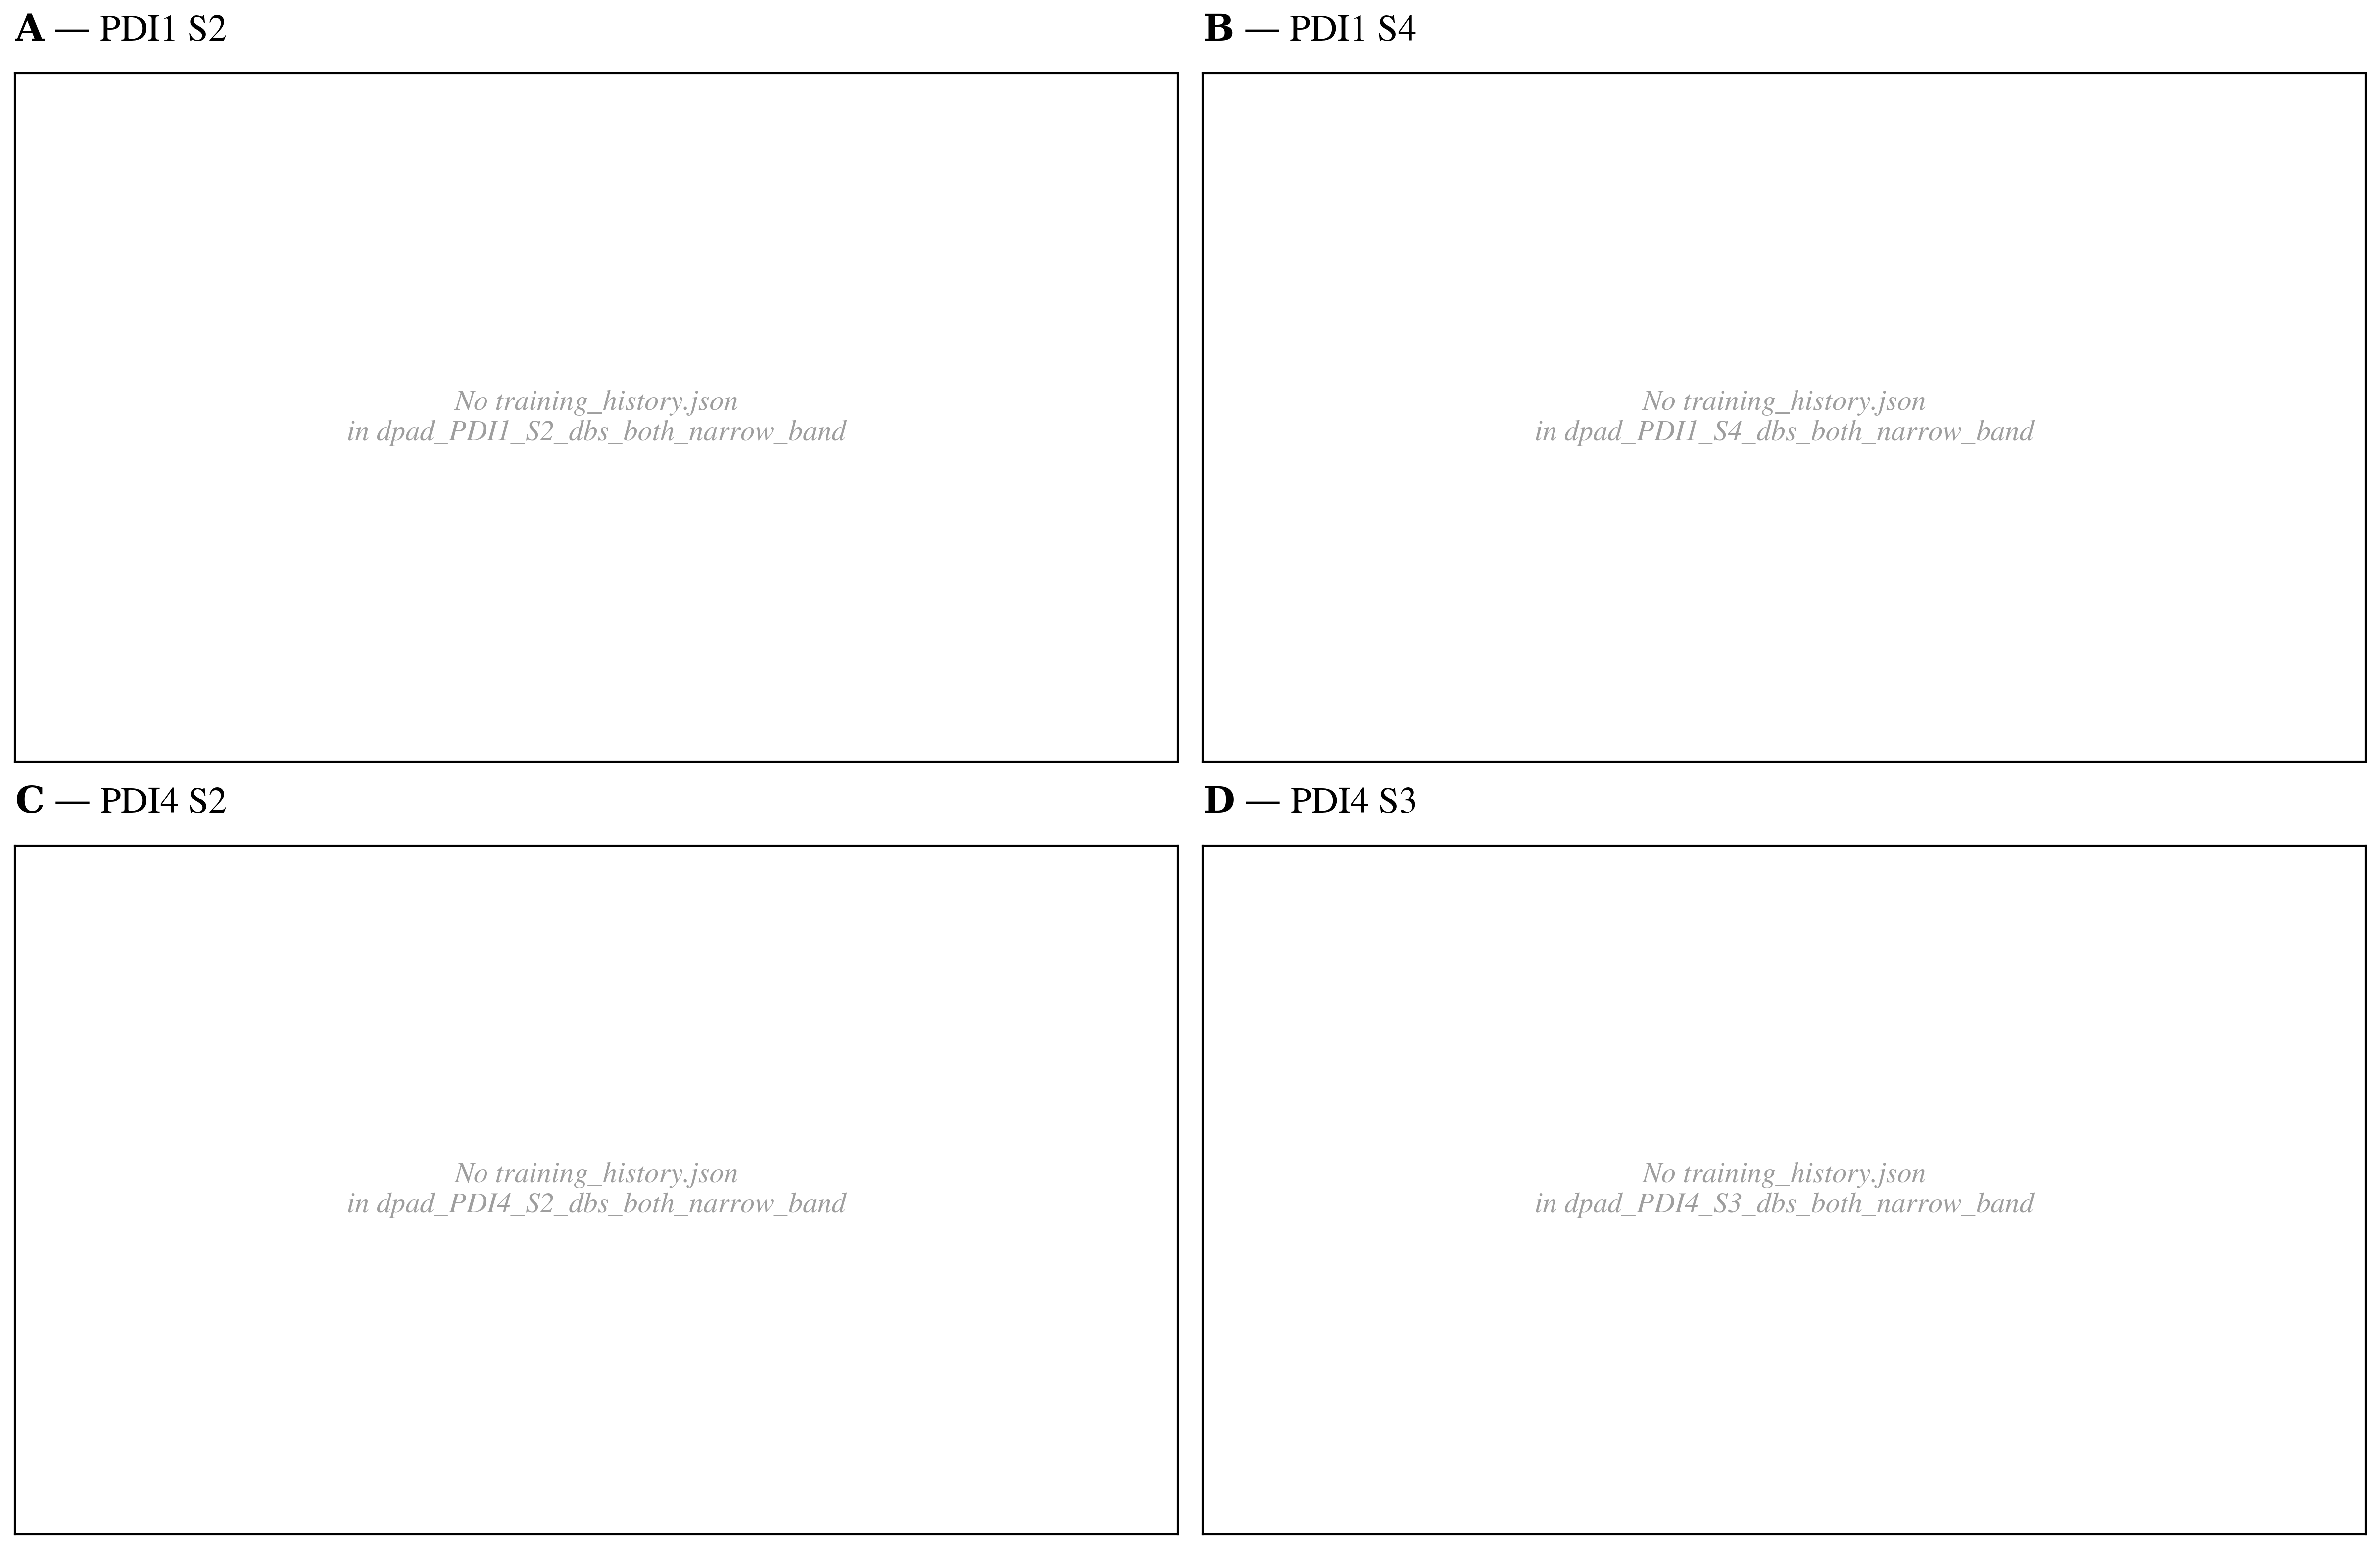

Fig 64 — DPAD 4-stage training curves (train = DPAD-red, val = PSID-blue dotted) concatenated across stages: model1 → model1_Cy → model2 → model2_Cz. Panels: PDI1 S2, PDI1 S4, PDI4 S2, PDI4 S3. Note: sessions may show 'No training_history.json' if DPAD retraining at 200 Hz is incomplete.


In [7]:
from typing import Any, Optional

_STAGE_KEYS = ["model1", "model1_Cy", "model2", "model2_Cz"]
_STAGE_RULE_COLOR = (0.4, 0.4, 0.4, 0.35)

_DPAD_SESSION_GLOBS = [
    "dpad_PDI1_S2_dbs_both_narrow_band",
    "dpad_PDI1_S4_dbs_both_narrow_band",
    "dpad_PDI4_S2_dbs_both_narrow_band",
    "dpad_PDI4_S3_dbs_both_narrow_band",
]
_SESSION_LABELS = ["PDI1 S2", "PDI1 S4", "PDI4 S2", "PDI4 S3"]


def _load_training_history(
    results_root_path: Path, dir_name: str
) -> Optional[Dict[str, Any]]:
    path = results_root_path / dir_name / "training_history.json"
    if not path.is_file():
        return None
    with open(path) as f:
        return json.load(f)


fig, axes = plt.subplots(2, 2, figsize=(8.0, 5.2))
panel_letters = ["A", "B", "C", "D"]

for idx, (dir_name, sess_label) in enumerate(zip(_DPAD_SESSION_GLOBS, _SESSION_LABELS)):
    r, c = divmod(idx, 2)
    ax = axes[r, c]

    hist = _load_training_history(results_root, dir_name)
    if hist is None:
        ax.text(
            0.5,
            0.5,
            f"No training_history.json\nin {dir_name}",
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=7,
            style="italic",
            color=COLOR_NS,
        )
        panel_label(ax, panel_letters[idx], sess_label)
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    cumulative_offset = 0
    stage_boundaries: List[int] = []
    all_epochs: List[float] = []
    all_loss: List[float] = []
    all_val_loss: List[float] = []

    for stage_key in _STAGE_KEYS:
        stage = hist.get(stage_key)
        if stage is None:
            continue
        epochs = stage.get("epochs", [])
        loss = stage.get("loss", [])
        val_loss = stage.get("val_loss", [])
        if not epochs or not loss:
            continue
        n = min(len(epochs), len(loss))
        cum_eps = [cumulative_offset + e for e in epochs[:n]]
        all_epochs.extend(cum_eps)
        all_loss.extend(loss[:n])
        if val_loss:
            nv = min(len(val_loss), n)
            all_val_loss.extend(val_loss[:nv])
            all_val_loss.extend([float("nan")] * (n - nv))
        else:
            all_val_loss.extend([float("nan")] * n)
        cumulative_offset += max(epochs[:n]) + 1
        stage_boundaries.append(cumulative_offset)

    if not all_epochs:
        ax.text(
            0.5,
            0.5,
            "no training data",
            ha="center",
            va="center",
            transform=ax.transAxes,
            style="italic",
            color=COLOR_NS,
        )
        panel_label(ax, panel_letters[idx], sess_label)
        continue

    show_leg = idx == 0
    for bx in stage_boundaries[:-1]:
        ax.axvline(bx, color=_STAGE_RULE_COLOR, linewidth=0.8, linestyle="--")

    ax.plot(
        all_epochs,
        all_loss,
        color=COLOR_DPAD,
        linewidth=1.5,
        label="Train loss" if show_leg else None,
    )
    if any(np.isfinite(v) for v in all_val_loss):
        ax.plot(
            all_epochs,
            all_val_loss,
            color=COLOR_PSID,
            linewidth=1.2,
            linestyle=":",
            label="Val loss" if show_leg else None,
        )

    if r == 1:
        ax.set_xlabel("Epoch")
    if c == 0:
        ax.set_ylabel("Loss")
    panel_label(ax, panel_letters[idx], sess_label)

fig.legend()
fig.savefig(str(OUT / "fig_064_dpad_training.png"))
plt.show()
print(
    "Fig 64 — DPAD 4-stage training curves (train = DPAD-red, val = PSID-blue dotted) "
    "concatenated across stages: model1 → model1_Cy → model2 → model2_Cz. "
    "Panels: PDI1 S2, PDI1 S4, PDI4 S2, PDI4 S3. "
    "Note: sessions may show 'No training_history.json' if DPAD retraining at 200 Hz is incomplete."
)

In [8]:
n = len(list(OUT.glob("*.png")))
print(f"Section 6 total: {n} figures")

Section 6 total: 6 figures
